In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [3]:
df = pd.read_csv("prediction_data_set.csv")
df.head()

,EmployeeID,Age,AgeGroup,Gender,Department,JobRole,Education,MaritalStatus,DateOfJoining,YearsAtCompany,...,ManagerRating,WorkLifeBalance,JobSatisfaction,Overtime,BurnoutRisk,AbsenteeismDays,Attrition,ExitReason,ExitDate,EmploymentStatus
0,100001,59,55+,Female,Finance,Clerk,PG,Married,14-11-2019,6,...,3,2,1,Yes,High Risk,26,No,Work Pressure,02-03-2022,Intern
1,100002,49,45-55,Male,Operations,Executive,PG,Single,01-04-2017,8,...,1,1,1,Yes,High Risk,7,No,Salary Issue,26-09-2023,Part Time
2,100003,35,35-44,Female,HR,Executive,UG,Married,06-11-2019,6,...,2,2,4,No,Normal,23,No,Work Pressure,22-06-2019,Intern
3,100004,28,25-34,Female,Operations,Analyst,PG,Married,26-11-2020,5,...,3,2,3,Yes,Normal,23,No,NaN,18-07-2020,Intern
4,100005,41,35-44,Male,HR,Executive,UG,Married,27-06-2010,15,...,4,4,4,Yes,Normal,1,No,Better Opportunity,31-07-2022,Intern


In [4]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

In [5]:
features = [
    "Age",
    "MonthlyIncome",
    "YearsAtCompany",
    "JobSatisfaction",
    "PerformanceRating",
    "Overtime"
]

X = df[features]
y = df["Attrition"]

In [6]:
X = pd.get_dummies(X, drop_first=True)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [9]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.809
Precision: 0.0
Recall: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
df["Attrition_Probability"] = model.predict_proba(X)[:, 1]

In [11]:
df[["EmployeeID", "Attrition_Probability"]].head()

,EmployeeID,Attrition_Probability
0,100001,0.210644
1,100002,0.196213
2,100003,0.202150
3,100004,0.204916
4,100005,0.200511


In [12]:
df.to_csv("HR_With_Predictions.csv", index=False)

from google.colab import files
files.download("HR_With_Predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

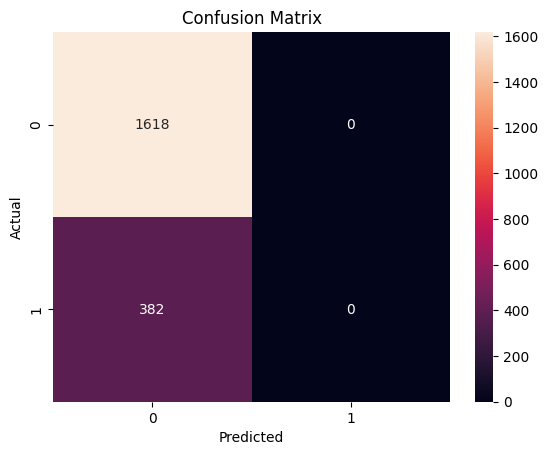

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

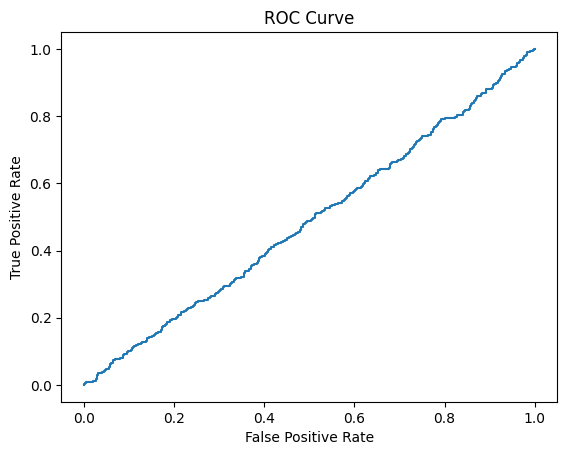

AUC: 0.486006575243174


In [14]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC:", roc_auc)

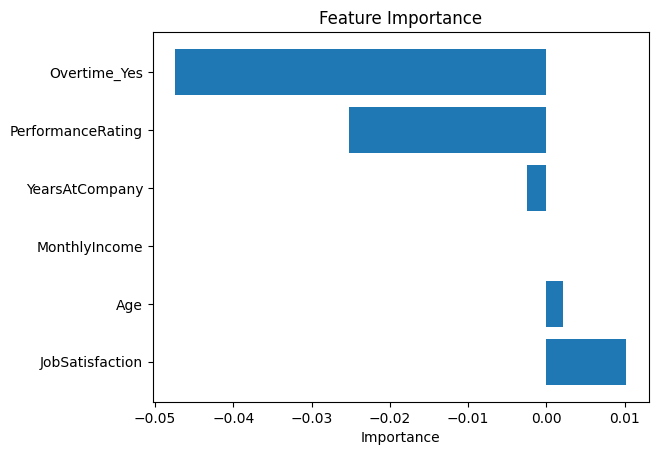

In [15]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_[0]
})

importance = importance.sort_values(by="Importance", ascending=False)

plt.figure()
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()